<a href="https://colab.research.google.com/github/Merigu10/03MIAR---Algoritmos-de-Optimizacion/blob/main/Trabajo_Pr%C3%A1ctico_Algoritmos).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Meritxell Guzmán Ventura  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/1ytl02tj51X1_10GXAppCestHcZF1Yo67?usp=sharing <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:

Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las
tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de
grabación independientemente del número de tomas que se graben. No es posible grabar más
de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los
servicios de los actores de doblaje sea el menor posible. Los datos son:



#Modelo
**- ¿Como represento el espacio de soluciones?**

Considerados los datos recibidos en un excel, observamos:


*   Cada fila representa una toma
*   Cada columna representa un actor
*   Si el actor participa en la toma suvalor es 1 y si no, es 0

Las variables de decisión seran 2:


*   Matriz de tomas asignadas por día (x)
  - Cada fila es un día
  - Cada columna es una toma
  - Si la toma se asigna a ese día, su valor es 1 y si no, es 0
*   Matriz de actores implicados por día (y)
  - Cada fila representa un día
  - Cada columna es un actor
  - Si el actor debe asistir a ese día su valor es 1 y si no, es 0


**- ¿Cual es la función objetivo?**
La función objetivo se trata de minimizar los días de rodaje de cada actor buscando la mejor asignación de tomas.
$$
f(x) = \min \sum_{i=1}^{D} \sum_{j=1}^{A} Y_{ij}
$$
Donde
*   D es el número total de días necesarios
*   A es el número total de actores
*   Y será 1 si el actor j trabaja el día i, y 0 para el caso contrario

**- ¿Como implemento las restricciones?**
* Un máximo de 6 tomas al día. Siendo T el total de tomas
$$
\sum_{j=1}^T X_{ij} <= 6
$$

* Una toma solo puede estar asociada a un único día-
$$
\sum_{i=1}^D X_{ij} = 1
$$
* Los actores deben coincidir en los días según las tomas.
$$
Y_{ik} >= X_{ij}
$$

In [ ]:
#Respuesta

#1. Representar los datos
import math
import random

tomasIniciales = [
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 0, 0, 1, 0, 0],
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0]
]

tomasTotales = 30
actoresTotales = 10
mejorSolucion = None
minDias = float('inf')

def asignar_tomas_aleatorio(tomas, maxTomasPorDia=6):
    """
    Asigna las tomas a los días de forma aleatoria para encontrar una primera solucion que no la óptima
    """
    tomasTotales = len(tomas)  # Número de tomas
    tomasDisponibles = set(range(tomasTotales))
    actoresTotales = 10 # Número de actores
    dias = [] # Matriz para guardar las tomas asignadas a cada día
    actores_asignados = set() #Lista para guardar las tomas asignadas a cada día

    while tomasDisponibles:
      tomasDia = [] #Las tomas que se harán ese día
      actoresPresentes = set() #Los actores que irán ese día
      for toma in random.sample(list(tomasDisponibles), len(tomasDisponibles)):  #Ordenamos por las tomas con mas actores
        # Verificamos que no excedamos el límite de 6 tomas por día
        if len(tomasDia) < maxTomasPorDia:
            tomasDia.append(toma)
            actoresPresentes.update(i for i in range(actoresTotales) if tomas[toma][i] == 1)
      # Guardamos las tomas asignadas a este día
      dias.append((tomasDia, actoresPresentes))

      # Eliminamos las tomas asignadas de la lista de disponibles
      tomasDisponibles -= set(tomasDia)

    return dias

def calcula_Coste(dias):
    """
    Calcula el coste total como el número total de días trabajados por los actores.
    """
    actoresTotales = 10  # Número total de actores
    actoresTrabajo = [0] * actoresTotales  # Inicializar la cuenta de días trabajados por actor

    for _, actores in dias:
        for actor in actores:
            actoresTrabajo[actor] += 1

    costeTotal = sum(actoresTrabajo)
    return costeTotal, actoresTrabajo


def imprimir_resultados(dias, costeTotal):
    """
    Imprime los resultados de la asignación de tomas y el coste total.
    """
    print(f"\n🔹 Mejor solución encontrada en {len(dias)} días con coste total de {costeTotal} días de trabajo:\n")

    for i, (tomasDia, actoresDia) in enumerate(dias):
        print(f"Día {i+1}: Tomas {tomasDia} | Actores {sorted(actoresDia)}")

for _ in range(100000):  # Encontrar la mejor opcion en un numero alto de ejecuciones, sin embargo no se puede garantizar un óptimo
    solucionActual = asignar_tomas_aleatorio(tomasIniciales)
    costeTotal, actoresTrabajo = calcula_Coste(solucionActual)

    if costeTotal < minDias:
        mejorSolucion = solucionActual
        minDias = costeTotal


imprimir_resultados(mejorSolucion, minDias)



🔹 Mejor solución encontrada en 5 días con coste total de 32 días de trabajo:

Día 1: Tomas [17, 27, 18, 23, 22, 16] | Actores [0, 2, 3, 5]
Día 2: Tomas [20, 3, 13, 11, 7, 28] | Actores [0, 1, 2, 3, 4, 5, 6, 7]
Día 3: Tomas [12, 21, 24, 15, 26, 1] | Actores [0, 1, 2, 3, 4, 9]
Día 4: Tomas [8, 0, 5, 19, 29, 6] | Actores [0, 1, 2, 3, 4]
Día 5: Tomas [2, 9, 25, 4, 14, 10] | Actores [0, 1, 2, 3, 4, 5, 6, 7, 8]


#Análisis
**- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones**

El máximo de días será 30/6 ya que no se puede hacer más de 6 tomas al día. Por lo tanto tendrémos un máximo de 5 días.
Debemos calcular todas las formas de repartir 30 tomas en grupos de tamaño máximo 6, sin repetir ninguna toma.

$$
\sum_{k=5}^{30/6}\frac{30!}{t_1! t_2! \dots t_k!}
$$

En el caso de encontrar la solución de manera aleatoria depende de las iteraciones que usemos, pero tiene una complejidad polinómica de
$$
O(nTA)
$$
Donde:
* n es el número de iteraciones
* T es el número de Tomas
* A es el número de Actores
En este caso:
$$
O(100000*30*10)
$$

Donde nos da una solución mejor que para un n bajo pero un tiempo de ejecución lento

   N Iteraciones  Tiempo (segundos)
0             10           0.000657
1            100           0.005410
2           1000           0.057468
3          10000           0.544352
4         100000           5.413836


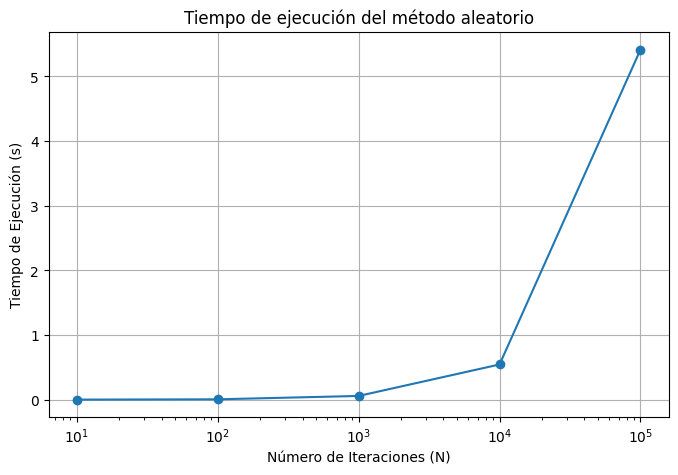

In [ ]:
#Respuesta
import time
import pandas as pd
import matplotlib.pyplot as plt

# Medir tiempos de ejecución
valores_N = [10, 100, 1000, 10000, 100000]
tiempoEjecucion = []

for N in valores_N:
    startTime = time.time()
    for _ in range(N):
        asignar_tomas_aleatorio(tomasIniciales)
    endTime = time.time()
    tiempoEjecucion.append(endTime - startTime)

# Crear DataFrame con los resultados
resultados = pd.DataFrame({"N Iteraciones": valores_N, "Tiempo (segundos)": tiempoEjecucion})
print(resultados)


plt.figure(figsize=(8, 5))
plt.plot(valores_N, tiempoEjecucion, marker='o', linestyle='-')
plt.xscale("log")
plt.xlabel("Número de Iteraciones (N)")
plt.ylabel("Tiempo de Ejecución (s)")
plt.title("Tiempo de ejecución del método aleatorio")
plt.grid(True)
plt.show()

#Diseño
**- ¿Que técnica utilizo? ¿Por qué?**

La primera opción usando asignaciones aleatorias es rápida, sencilla y te encuentra una mínimo pero no te garantiza un óptimo.
Para encontrar una solución que escape de mínimos locales y rápida se puede usar un algoritmo de Recocido Simulado que tiene una complejidad de:
$$
O(TA  \log T)
$$

Mejor coste encontrado (Recocido Simulado): 32
Día 1: Tomas [[22, 15, 19, 25, 10, 21], {0, 1, 2, 3, 4, 9}]
Día 2: Tomas [[28, 6, 3, 20, 27, 24], {0, 1, 2, 3, 4, 5, 6, 7}]
Día 3: Tomas [[11, 23, 4, 0, 7, 1], {0, 1, 2, 3, 5}]
Día 4: Tomas [[9, 26, 12, 17, 29, 13], {0, 1, 2, 3, 4, 6}]
Día 5: Tomas [[18, 5, 2, 16, 14, 8], {0, 1, 2, 3, 4, 5, 8}]
   N Iteraciones  Tiempo (segundos)
0             10           0.000446
1            100           0.002737
2           1000           0.023201
3          10000           0.186118
4         100000           1.512688


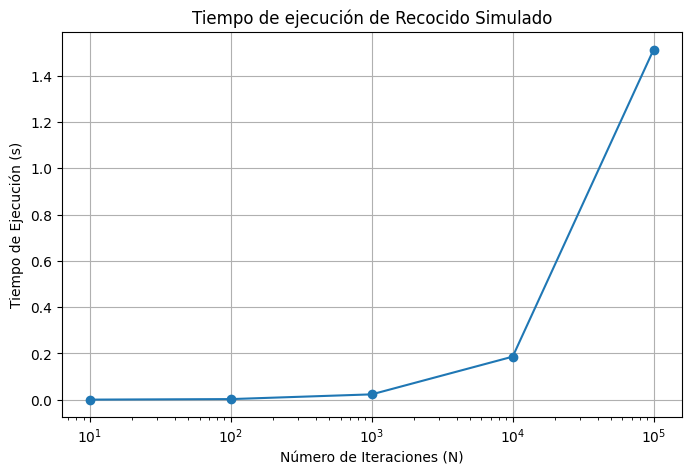

In [ ]:
#Respuesta
#Generamos una solución inicial aleatoria (se aprovecha la funcion hecha al inicio, de asignar_tomas_aleatorio )
#Aprovechamos las funciones asignar_tomas_aleatorio y calcula_Coste  para crear la solucion inicial

#Creamos una funcion para generar vecinos de la solucion

def alterar_solucion(dias):
    nuevaSolucion = [list(dia) for dia in dias]
    if len(nuevaSolucion) > 1:
        d1, d2 = random.sample(range(len(nuevaSolucion)), 2)
        if nuevaSolucion[d1][0] and nuevaSolucion[d2][0]:
            t1 = random.choice(nuevaSolucion[d1][0])
            t2 = random.choice(nuevaSolucion[d2][0])
            nuevaSolucion[d1][0].remove(t1)
            nuevaSolucion[d2][0].remove(t2)
            nuevaSolucion[d1][0].append(t2)
            nuevaSolucion[d2][0].append(t1)
            nuevaSolucion[d1][1] = {i for i in range(actoresTotales) if any(tomasIniciales[t][i] for t in nuevaSolucion[d1][0])}
            nuevaSolucion[d2][1] = {i for i in range(actoresTotales) if any(tomasIniciales[t][i] for t in nuevaSolucion[d2][0])}
    return nuevaSolucion

# Recocido Simulado

def recocido_simulado(temperaturaInicial=1000, enfriamiento=0.995, iteraciones=100000):
    solucionActual = asignar_tomas_aleatorio(tomasIniciales)
    costeTotalActual, actoresTotales = calcula_Coste(solucionActual)
    mejorSolucion = solucionActual[:]
    mejorCosteActual = costeTotalActual
    temperatura = temperaturaInicial

    for _ in range(iteraciones):
        nuevaSolucion = alterar_solucion(solucionActual)
        nuevoCosteTotal, actoresTotales = calcula_Coste(nuevaSolucion)

        if nuevoCosteTotal < mejorCosteActual or random.random() < math.exp((mejorCosteActual - nuevoCosteTotal) / temperatura):
            mejorSolucion = nuevaSolucion
            mejorCosteActual = nuevoCosteTotal

            if nuevoCosteTotal < mejorCosteActual:
                mejorSolucion = nuevaSolucion[:]
                mejorCosteActual = nuevoCosteTotal

        temperatura *= enfriamiento

    return mejorSolucion, mejorCosteActual

# Ejecutar Recocido Simulado
mejorSolucion, mejorCoste = recocido_simulado()

# Mostrar resultados
print(f"Mejor coste encontrado (Recocido Simulado): {mejorCoste}")
for i, tomasDia in enumerate(mejorSolucion):
    print(f"Día {i+1}: Tomas {tomasDia}")

# Graficar el tiempo de ejecución
valores = [10, 100, 1000, 10000, 100000]
tiempoEjecucion = []

for N in valores:
    startTime = time.time()
    recocido_simulado(iteraciones=N)
    endTime = time.time()

    tiempoEjecucion.append(endTime - startTime)

# Crear DataFrame con los resultados
df_resultados = pd.DataFrame({"N Iteraciones": valores, "Tiempo (segundos)": tiempoEjecucion})
print(df_resultados)

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(valores, tiempoEjecucion, marker='o', linestyle='-')
plt.xscale("log")
plt.xlabel("Número de Iteraciones (N)")
plt.ylabel("Tiempo de Ejecución (s)")
plt.title("Tiempo de ejecución de Recocido Simulado")
plt.grid(True)
plt.show()
